In [1]:
from utilities import DataSimulator, prepare_data,plot_learning_curve, analyze_error_distribution, ks_test_gan_cdf,plot_bin_dist 
from my_cGAN import MyCGAN
import pandas as pd
import numpy as np


# DATA MANAGEMENT

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 3        # Number of time steps
J = 2        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.get_paths()
sim.get_pdf(n_steps_ahead=10, n_bins=3)
sim.save_binary_file('data/inputs/demo')
print(sim.paths)
print(sim.pdf)

file stored in data/inputs/demo.bin
[[ 0.77395605  0.77946721  0.76059986  0.75817074]
 [ 0.43887844 -0.20028035  0.1364279   0.41590248]]
[[ 0.4310977   0.74310273  1.05510775]
 [-4.37205315 -1.17057509  2.03090298]]


In [6]:
file_paths, file_pdf = sim.load_binary_file('data/inputs/demo.bin')

8
8
0
processed binary file


In [7]:
print(file_paths)
print(file_pdf)

[[ 0.77395605  0.77946721  0.76059986  0.75817074]
 [ 0.43887844 -0.20028035  0.1364279   0.41590248]]
[[ 0.4310977   0.74310273  1.05510775]
 [-4.37205315 -1.17057509  2.03090298]]


# MEAN AND VARIANCE

In [2]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10)

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='standardization')


conditional_gan = MyCGAN(max_epoch= 100, name = 'CGAN_mean_std')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1])
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'mean_std_error_dist.csv')


Epoch: 0/100, Step: 0, D Loss: 1.4059211015701294, G Loss: 0.7193750739097595
Epoch: 0/100, Step: 500, D Loss: 1.3669769763946533, G Loss: 0.6678935885429382
Epoch: 0/100, Step: 1000, D Loss: 1.3883306980133057, G Loss: 0.6988725066184998
Epoch: 0/100, Step: 1500, D Loss: 1.391775131225586, G Loss: 0.6957070827484131


c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\my_cGAN.py:427: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  D_loss_list.append(round(float(D_loss), 4))


Epoch: 0/100, Step: 2000, D Loss: 1.3888027667999268, G Loss: 0.7002123594284058
Epoch: 0/100, Step: 2500, D Loss: 1.3779631853103638, G Loss: 0.7002137303352356
Epoch: 0/100, Step: 3000, D Loss: 1.3795013427734375, G Loss: 0.6887571811676025
Epoch: 1/100, Step: 3500, D Loss: 1.3750343322753906, G Loss: 0.7187780141830444
Epoch: 1/100, Step: 4000, D Loss: 1.3772921562194824, G Loss: 0.7514622807502747
Epoch: 1/100, Step: 4500, D Loss: 1.383636713027954, G Loss: 0.6858837008476257
Epoch: 1/100, Step: 5000, D Loss: 1.3833900690078735, G Loss: 0.714773416519165
Epoch: 1/100, Step: 5500, D Loss: 1.3675181865692139, G Loss: 0.7177178263664246
Epoch: 1/100, Step: 6000, D Loss: 1.3695335388183594, G Loss: 0.7729098796844482
Epoch: 2/100, Step: 6500, D Loss: 1.3087921142578125, G Loss: 0.9587804675102234
Epoch: 2/100, Step: 7000, D Loss: 1.1416065692901611, G Loss: 1.072570562362671
Epoch: 2/100, Step: 7500, D Loss: 1.0106561183929443, G Loss: 1.8137062788009644
Epoch: 2/100, Step: 8000, D Los

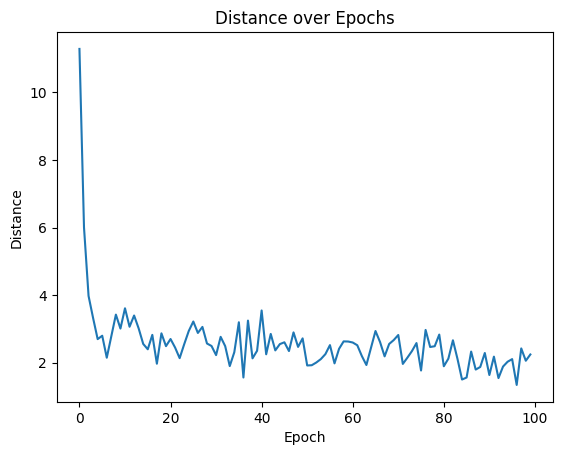

In [4]:
plot_learning_curve('generated_vs_true.csv')

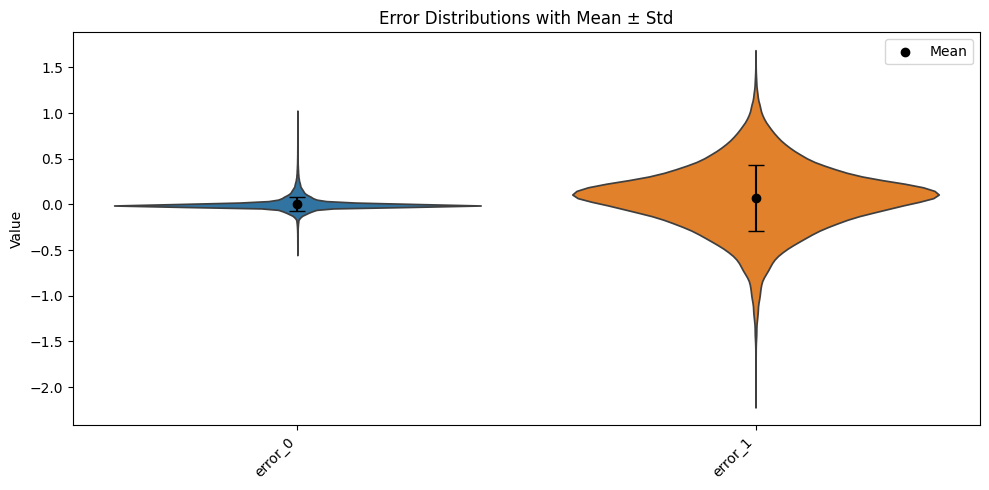

error_0    0.005486
error_1    0.075123
dtype: float64 
 error_0    0.074646
error_1    0.360826
dtype: float64 
              mean       std    median      skew   kurtosis  is_zero_test
error_0  0.005486  0.074646 -0.008105  2.326250  14.010289         False
error_1  0.075123  0.360826  0.089637 -0.247794   1.304691         False


In [2]:
means, std, summary = analyze_error_distribution('./data/results/mean_std_error_dist.csv')
print(means,'\n', std, '\n', summary)

# BINS DISTRIBUTION


In [8]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100, verbose=True)
pdfs

Mean values - unique: (100,), min: -2.0448548406664235, max: 2.0784605024823306
Std values - unique: (100,), min: 0.0029726035560525615, max: 0.19513922000154846
First 5 means: [ 0.58455083 -1.18721202  0.57648137  0.69446668  0.08626536]
First 5 stds: [0.15490709 0.19359807 0.09984949 0.02883561 0.0029726 ]
First 3 samples' first 5 bin edges:
[[-0.03507754 -0.02268497 -0.0102924   0.00210016  0.01449273]
 [-1.9616043  -1.94611645 -1.93062861 -1.91514076 -1.89965292]
 [ 0.17708342  0.18507138  0.19305934  0.2010473   0.20903526]]
Are all rows identical? False
First 3 samples' first 5 bin edges standardized:
[[-4.   -3.92 -3.84 -3.76 -3.68]
 [-4.   -3.92 -3.84 -3.76 -3.68]
 [-4.   -3.92 -3.84 -3.76 -3.68]]
Are all rows identical standardized? True
Are all probability rows identical? True


array([[1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       ...,
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05]], shape=(100, 100))

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
pdfs

Are all probability rows identical? True


array([[1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       ...,
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05]],
      shape=(1000, 100))

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_fake')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'bins_error_dist_todelete.csv')


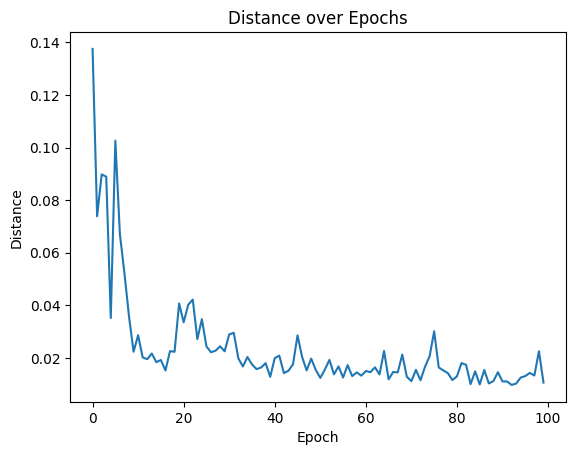

In [11]:
plot_learning_curve('generated_vs_true.csv')

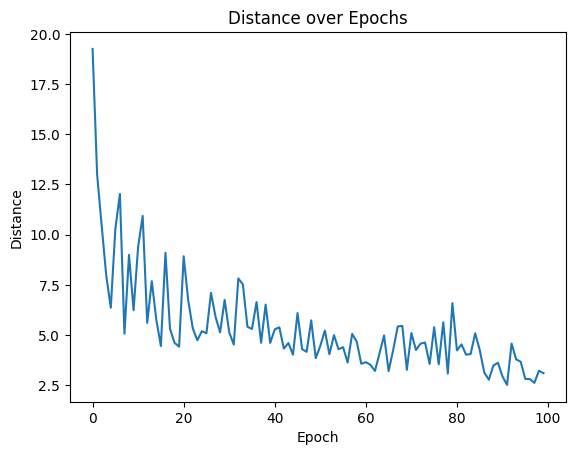

In [4]:
plot_learning_curve('generated_vs_true.csv')

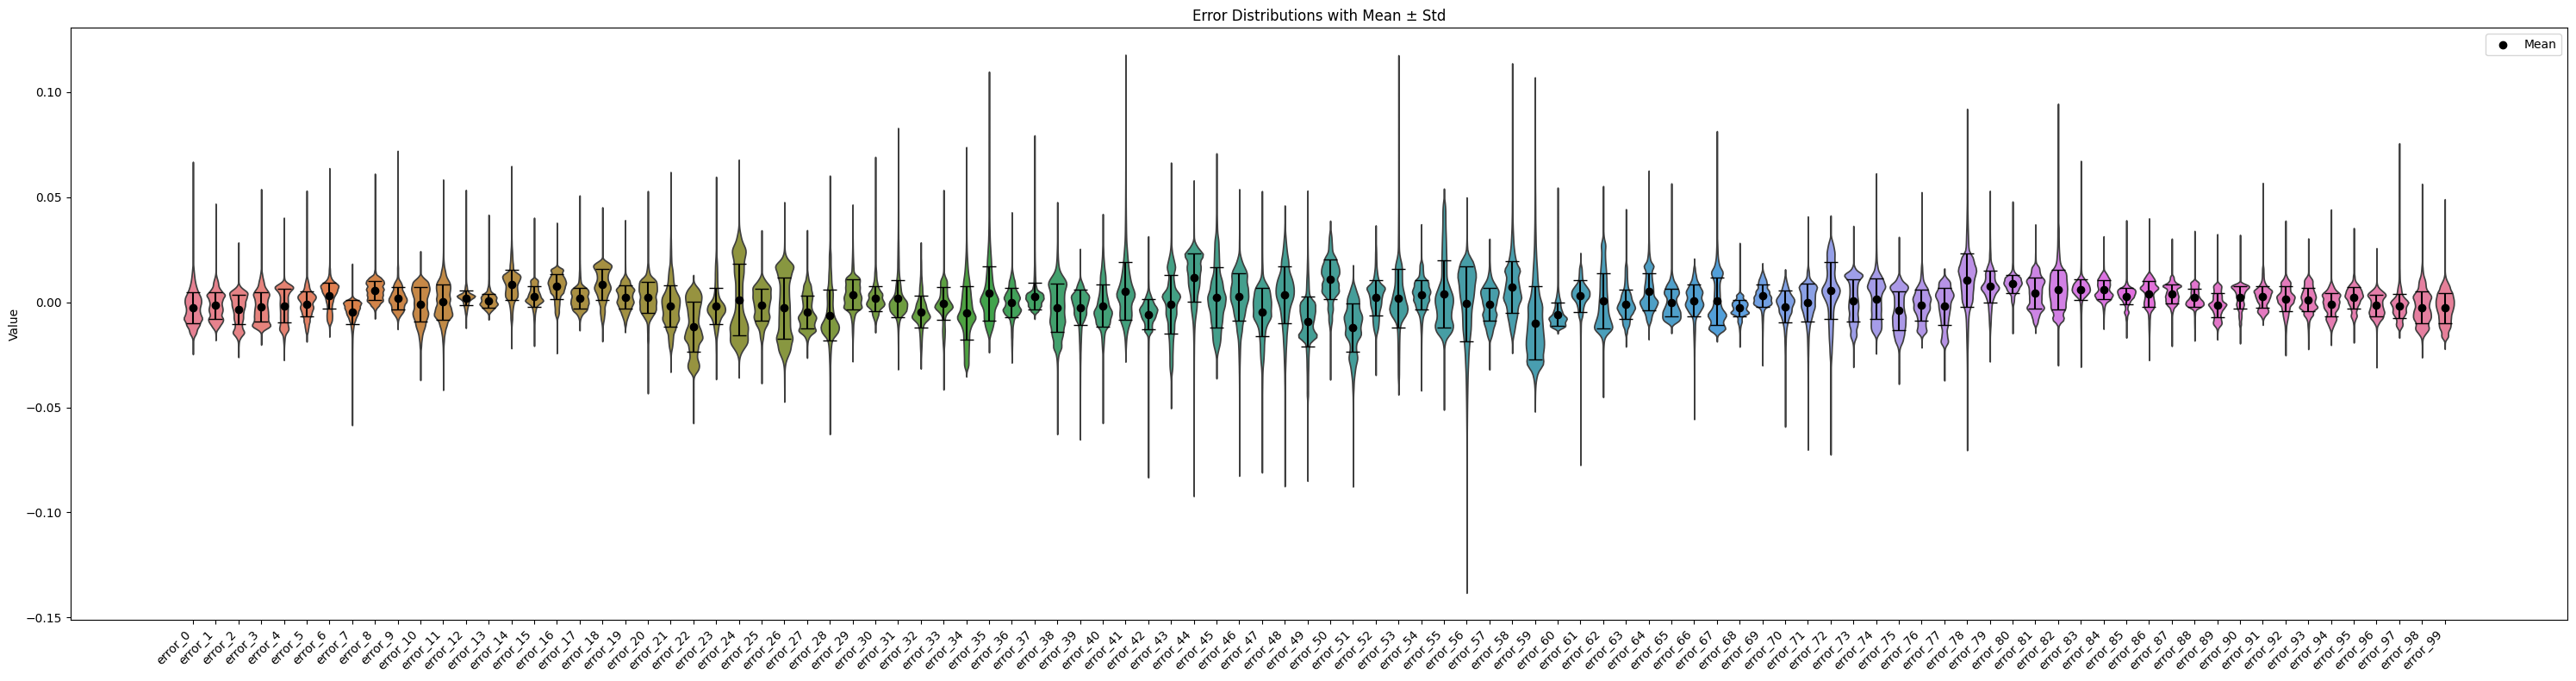

error_0    -0.002629
error_1    -0.001518
error_2    -0.003471
error_3    -0.002169
error_4    -0.001636
              ...   
error_95    0.002152
error_96   -0.001471
error_97   -0.001816
error_98   -0.002500
error_99   -0.002640
Length: 100, dtype: float64 
 error_0     0.007401
error_1     0.006244
error_2     0.007125
error_3     0.006982
error_4     0.007943
              ...   
error_95    0.005025
error_96    0.005132
error_97    0.005814
error_98    0.007606
error_99    0.007172
Length: 100, dtype: float64 
               mean       std    median      skew  kurtosis  is_zero_test
error_0  -0.002629  0.007401 -0.002944  0.372987  0.066468         False
error_1  -0.001518  0.006244 -0.001509  0.096317 -0.757230         False
error_2  -0.003471  0.007125 -0.002174 -0.385574 -0.997832         False
error_3  -0.002169  0.006982 -0.002577  0.266079 -0.721484         False
error_4  -0.001636  0.007943 -0.000736 -0.294469 -1.031563         False
...            ...       ...       ...  

In [5]:
means, std, summary = analyze_error_distribution('./data/results/bins_error_dist.csv')
print(means,'\n', std, '\n', summary)

In [ ]:
summary

# ks test 

In [10]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=1

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = val.get_paths()
pdfs= val.get_pdf(n_steps_ahead=10, n_bins=100)

Are all probability rows identical? True


In [11]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins')
conditional_gan.load_models()

CGAN config loaded from ./models\CGAN_bins_config.json
Generator loaded from ./models\CGAN_bins_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [128, 256, 128], 'use_batch_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0, 'is_prob': True}
Discriminator loaded from ./models\CGAN_bins_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [256, 128], 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}


In [18]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)


In [19]:
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df

,p_values
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
95,1.0
96,1.0
97,1.0
98,1.0


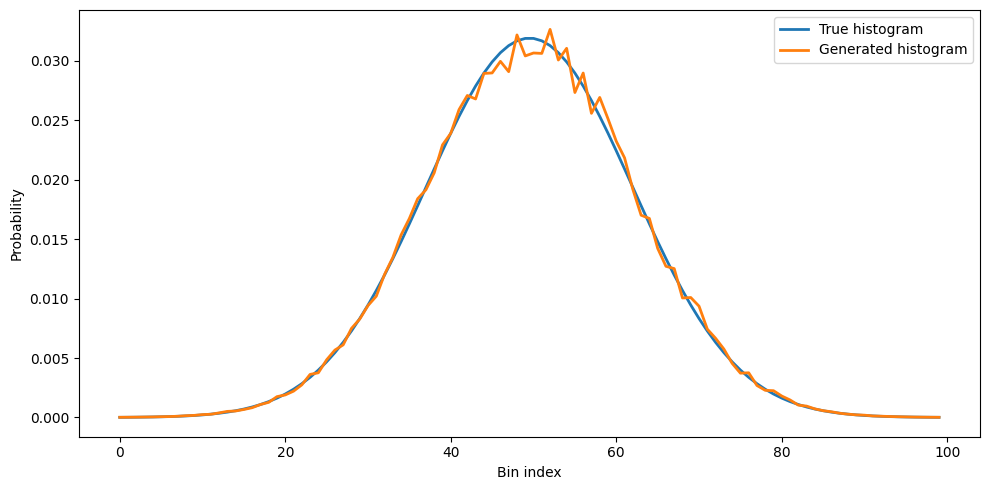

In [20]:
generated_sample = generated[-1]
true_sample = pdfs[-1]

plot_bin_dist(true_sample, generated_sample)

